# Maths into Data Science and AI
# Exploratory data analysis

## *Using this notebook*
As you work through this notebook you will:
* **run code** and look at  the results
* **make changes** to the code and see how that changes the results
*  **add your own code** to complete further exploratory analysis

## *Make your own copy*
Before you go any further, make your own personal copy of this notebook. You will need your own Kaggle account so that any changes you make to your copy are saved. Look for the button in the top right corner of this window. It says 'copy and edit'. Click this button. It might take a few seconds to create the copy. Open your copy and continue reading down this page.

**Good practice is to press Run All (next to the double arrows at the top of the page) as soon you have made your own copy of the notebook. You can then run any individual code block by clicking the arrow next to it.**

## Introduction
### Data context
The data set shows bicycle hires over two years for a bike hire scheme in Washington, DC. Each row represents an hour of a day and records the number of bikes hired along with some other information like the weather conditions, type of hire and date.

### Data features

| Feature   | Description       | Notes
| ---       | ---               |   --- |
| **dteday**| Date              |
| **season**| Season            |
| **hr**    | Hour of the day   | 0 - 23
| **workingday**| Working day or weekend/holiday| 0 = holiday or weekend
|               |                               | 1 = working day
| **weathersit**| Weather situation| 1 = Clear, Few clouds, Partly cloudy, Partly cloudy
|               |                  |2 = Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
|               |                  |3 = Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
|               |                  |4 = Heavy Rain + Hail + Thunderstorm + Mist, Snow + Fog
| **temp**      | Temperature in Celsius |°C
| **atemp**     | 'Feeling' temperature |°C
| **hum**       | Humidity |%
| **windspeed** | Windspeed |knots
| **casual**    | Number of casual hires|
| **registered**| Number of hires by registered users|


## Importing libraries and data

### Importing the libraries

In [ ]:
# Import the pandas data analysis library
import pandas as pd

# Import the seaborn visualisation library
import seaborn as sns

# As seaborn updates sometimes we see warnings
import warnings
warnings.simplefilter(action='ignore')

### Importing the dataset

In [ ]:
#import the data
bike_data = pd.read_csv('/kaggle/input/bike-hires/hourly bike hires.csv')

# Use .head() to see the top of the dataframe
bike_data.head()

## Preparing the Data

In [ ]:
# check the feature names and data types 
bike_data.info()

* `dteday` and `season`are text
* All of the other features are integers
* There are no null values

In [ ]:
# find summary statistics of the numerical features
bike_data.describe()

## Feature Engineering

Before analysing the data it will be useful to create some new features based on existing features in the table. This is called _feature engineering_. 

In the code below you can see how to:
* Create a new numerical feature.
* Create text features for categories that have been recorded as numbers.

 **Creating a new numerical feature**
 
The data gives separate values for 'registered' and 'casual' hires. You can combine these to create a new feature for the total number of hires.

In [ ]:
# create a new numerical feature from a function of existing features
bike_data['total'] = bike_data['casual'] + bike_data['registered']

# display the data to check
bike_data.head()

**Creating a new text feature from a numerical feature**

It is common for categorical features to be stored as numbers in data sets. For example, in this data set the `weathersit` feature has stored the weather situations using numbers from 1-4. This is a categorical feature and not a numerical feature: taking an average of these numbers would not make sense in this context. 

So it is helpful to make a new text feature for categories that are represented as numbers in the original data set. You can then use the new feature to make your exploratory data analysis clearer. 

In [ ]:
# the replace dictionary uses a colon to indicate what is to be replaced and commas to separate the items

# replace numbers with categories
bike_data['weather'] = bike_data['weathersit'].replace({1: 'Clear', 2: 'Cloud', 3: 'Rain', 4: 'Heavy rain'})

# display the data to check
bike_data.head()

### Task 1
The `workingday` feature is also a categorical feature that has been stored as a number. 

> Copy the code from above and change it to create a new feature called `weekday`, based on `workingday`, that replaces `0` with `'Weekend'` and `1` with `'Weekday'`.

In [ ]:
# create a new text feature for weekday


## Visualisations

In [ ]:
# create a basic distribution plot 
sns.displot(data=bike_data, x='total', aspect=2); 

This shows the *distribution* of hourly bike rentals. Most hours have low usage; however, there are a few very busy hours.

In [ ]:
# Do bike hires vary by season?
sns.catplot(data=bike_data, kind='box', x='total', y='season', aspect=2);

In [ ]:
# Group the data by season
bike_data.groupby('season')['total'].describe().round(2)

Are weekdays consistently different from weekends across seasons?

In [ ]:
# Create split violin plots
sns.catplot(data=bike_data, kind='violin', x='total', y='season', hue='workingday', split=True);

Does temperature influence hourly bike rentals?

In [ ]:
# create a scatter plot
sns.relplot(data=bike_data, kind='scatter', x='temp', y='total', aspect=2, alpha=0.4);

You can summarise your findings from these visualisations:
* It is more common to have a lower amount of hires each hour
* Winter is much less popular than the other seasons
* Weekends seem to have a steady average hourly hire.
* Weekday usage is split, some hours are very quiet but there is also a peak around 200 hires per hour
* There seems to be a slight tendency towards hires in higher temperatures


### Task 2

Explore:
* How do hourly bike hires vary by weather situation?
* How are weekdays different from weekends for each weather situation?
* Whether any of the other weather features influence hourly bike rentals.
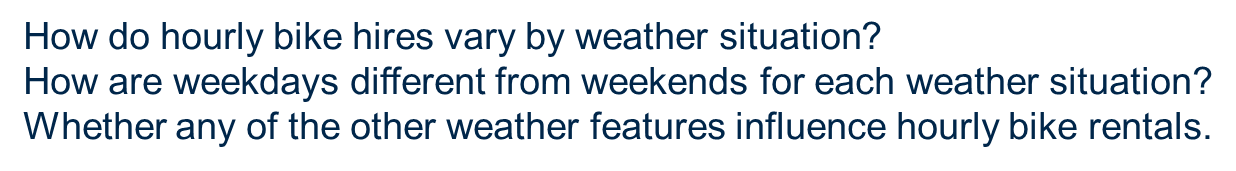
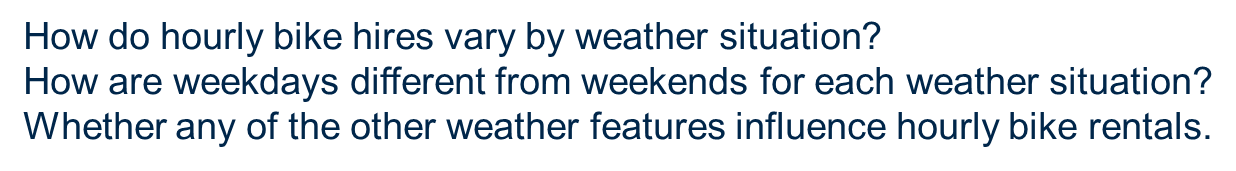
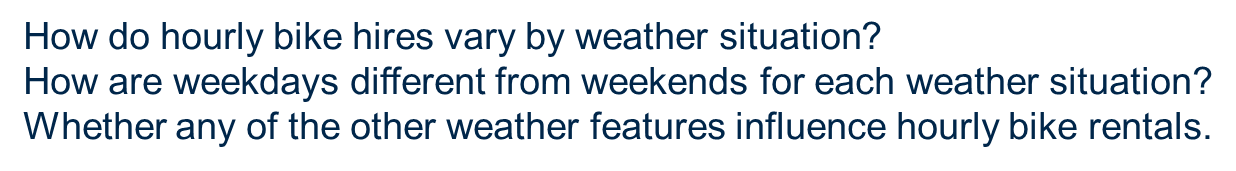
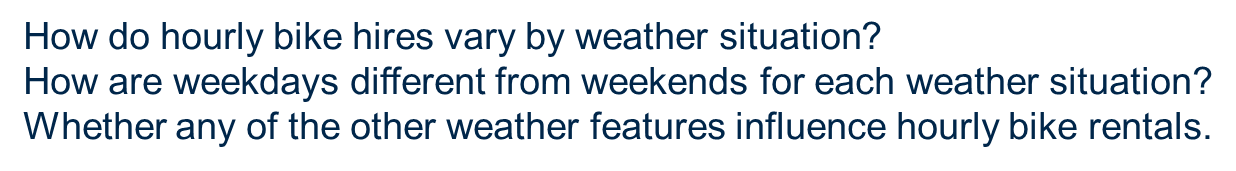

**Do hourly bike hires vary by weather situation?**

**Are weekdays consistently different from weekends across each weather situation?**

**Do any of the other weather features seem to influence hourly bike rentals?**

### Task 2 - Check your work
1. If you have used a boxplot you should see that the medians of Spring, Summer and Autumn are around 150-200 whereas the median of Winter is about 75.
2. On a violin plot you may have noticed that rain seems to have a similar distribution, where as clear and cloud do not. There are no non-working day bike hires in heavy rain.


## Slicing the data

When exploring a big data set you sometimes wish to filter out some subset of the data. This is known as *slicing* the data.

Weekdays seemed to show a different distribution to weekends. Commuters and leisure hires will use the scheme completely differently. 

**If you look at only weekend hours, do factors like the weather still affect how many bikes are hired?** 

In [ ]:
# create a slice of the data with just non-working days
weekend_data = bike_data[bike_data['workingday'] == 0].copy()

# check the data
weekend_data.head()

Does temperature influence weekend hourly bike rentals?

In [ ]:
# create a scatter plot
sns.relplot(data=weekend_data, kind='scatter', x='temp', y='total', alpha=0.4, aspect =2); 

Do weekend bike hires vary by weather?

In [ ]:
# create a boxplot
sns.catplot(data=weekend_data, kind='box', x='total', y='weather', aspect=2);

### Task 3

Explore:

* What factors affect bike hires in winter?
* What factors affect bike hires when the weather is clear?
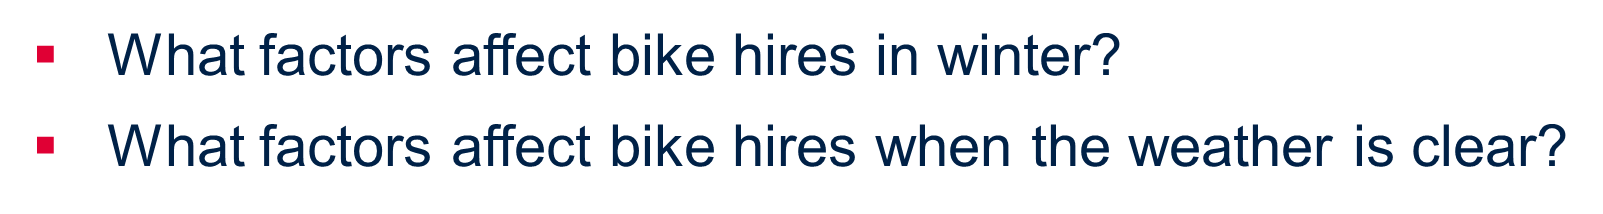
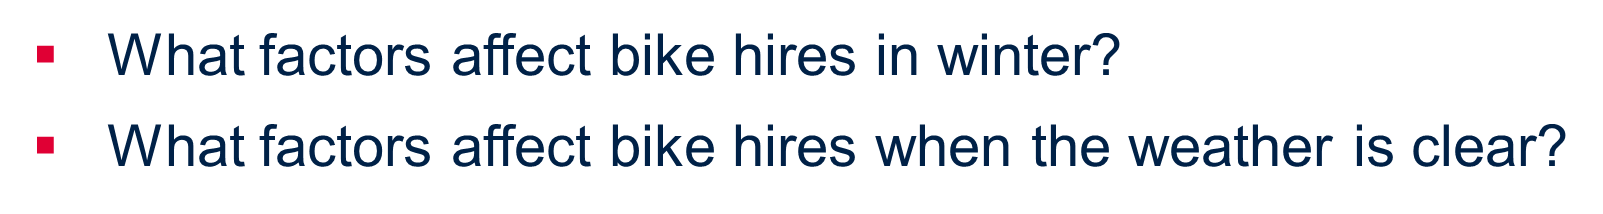
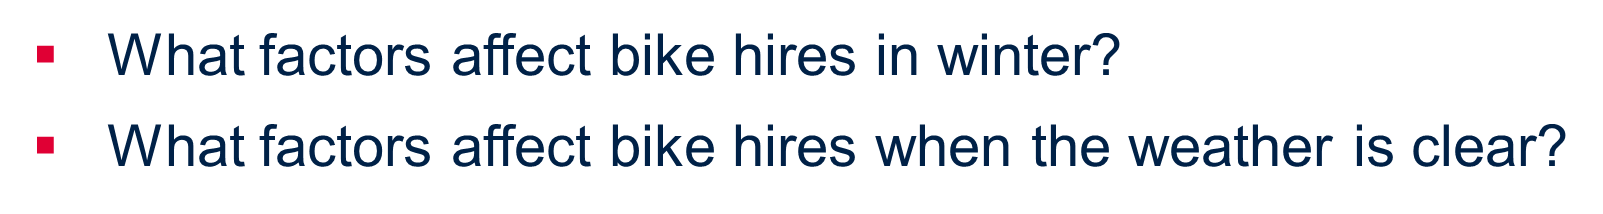
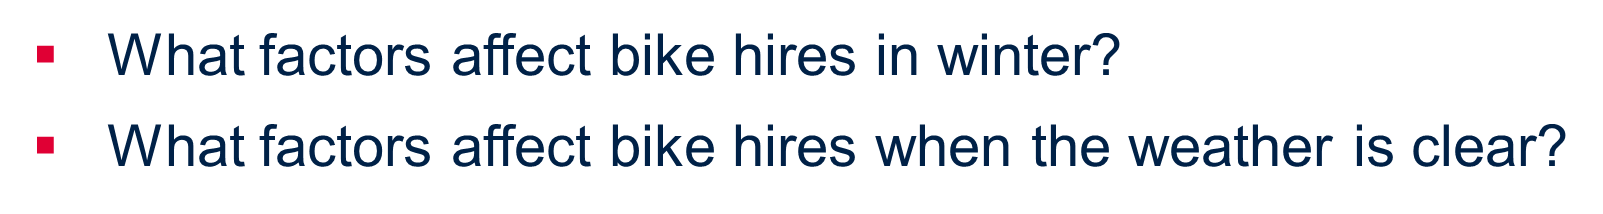

In [ ]:
# create a slice of the data with just winter days
winter_data = bike_data[bike_data['season'] == 'Winter'].copy()

# check the data
winter_data

Use visualisations to explore what factors affect the hourly bike hire in winter.

In [ ]:
# create a slice of the data with just clear weather days


Use visualisations to explore what other factors affect bike hire when the weather is clear.